<a href="https://colab.research.google.com/github/Tanxinru05/mem-gnn-rnn-continuous-prediction/blob/main/Power_Plant__noise_injection_all_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import requests
from sklearn.preprocessing import StandardScaler
import joblib
from zipfile import ZipFile
from io import BytesIO
from tqdm import tqdm

# --- Configuration ---
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'
EXCEL_FILENAME = 'CCPP/Folds5x2_pp.xlsx'
TARGET_COLUMN = 'PE' # Net hourly electrical energy output
LOOKBACK_WINDOW = 10

# --- NEW: Robustness Test Configuration ---
# Set to a feature name ('AT', 'V', 'AP', 'RH') to shuffle it.
# Set to None to run the original preprocessing without shuffling.
COLUMN_TO_SHUFFLE = 'AT'
# For reproducible shuffles
RANDOM_SEED = 42

def preprocess_hybrid_data():
    """
    Downloads, preprocesses, and saves the CCPP dataset.
    Includes an optional step to shuffle a feature column for robustness testing.
    """
    # Set seed for reproducibility of the shuffle
    if COLUMN_TO_SHUFFLE:
        np.random.seed(RANDOM_SEED)

    print("--- 1. Downloading and Loading CCPP Data ---")
    if not os.path.exists('Folds5x2_pp.xlsx'):
        print(f"Downloading data...")
        response = requests.get(DATA_URL)
        response.raise_for_status()
        with ZipFile(BytesIO(response.content)) as z:
            with z.open(EXCEL_FILENAME) as f:
                with open('Folds5x2_pp.xlsx', 'wb') as out_f:
                    out_f.write(f.read())

    df = pd.read_excel('Folds5x2_pp.xlsx')
    print("Data loaded successfully.")

    print("--- 2. Preparing and Scaling Data ---")
    y = df[[TARGET_COLUMN]]
    X = df.drop(columns=[TARGET_COLUMN])

    # Scale features and target
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_scaled = x_scaler.fit_transform(X)
    y_scaled = y_scaler.fit_transform(y)

    # --- NEW: Shuffle a Column for Robustness Test ---
    if COLUMN_TO_SHUFFLE:
        print(f"--- 2a. Shuffling column: '{COLUMN_TO_SHUFFLE}' for robustness test --- 🎲")
        try:
            # Get the integer index of the column to shuffle
            col_index = X.columns.get_loc(COLUMN_TO_SHUFFLE)

            # Shuffle the column in-place within the scaled numpy array
            np.random.shuffle(X_scaled[:, col_index])

            print(f"Column '{COLUMN_TO_SHUFFLE}' (index {col_index}) has been successfully shuffled.")
        except KeyError:
            print(f"Error: Column '{COLUMN_TO_SHUFFLE}' not found in the dataset. No column was shuffled.")
            print(f"Available columns are: {list(X.columns)}")
    # --- END OF NEW SECTION ---

    joblib.dump(x_scaler, 'x_scaler_ccpp_hybrid.gz')
    joblib.dump(y_scaler, 'y_scaler_ccpp_hybrid.gz')

    def create_hybrid_sequences(features, target, lookback):
        X_seq, y_seq = [], []
        current_features = features
        for i in tqdm(range(lookback, len(features)), desc="Creating Hybrid Sequences"):
            history_seq = features[i-lookback:i, :]
            current_features_tiled = np.tile(current_features[i, :], (lookback, 1))
            combined_seq = np.concatenate([history_seq, current_features_tiled], axis=1)
            X_seq.append(combined_seq)
            y_seq.append(target[i, :])
        return np.array(X_seq), np.array(y_seq)

    print("--- 3. Creating Hybrid Sequences ---")
    X_seq, y_seq = create_hybrid_sequences(X_scaled, y_scaled, LOOKBACK_WINDOW)

    print("--- 4. Splitting and Saving Data ---")
    train_size = int(len(X_seq) * 0.7); val_size = int(len(X_seq) * 0.15)

    np.save('X_train_ccpp_hybrid.npy', X_seq[:train_size])
    np.save('y_train_ccpp_hybrid.npy', y_seq[:train_size])
    np.save('X_val_ccpp_hybrid.npy', X_seq[train_size:train_size + val_size])
    np.save('y_val_ccpp_hybrid.npy', y_seq[train_size:train_size + val_size])
    np.save('X_test_ccpp_hybrid.npy', X_seq[train_size + val_size:])
    np.save('y_test_ccpp_hybrid.npy', y_seq[train_size + val_size:])

    print("\nPreprocessing for hybrid models complete.")

if __name__ == '__main__':
    preprocess_hybrid_data()

--- 1. Downloading and Loading CCPP Data ---
Data loaded successfully.
--- 2. Preparing and Scaling Data ---
--- 2a. Shuffling column: 'AT' for robustness test --- 🎲
Column 'AT' (index 0) has been successfully shuffled.
--- 3. Creating Hybrid Sequences ---


Creating Hybrid Sequences: 100%|██████████| 9558/9558 [00:00<00:00, 101360.41it/s]

--- 4. Splitting and Saving Data ---

Preprocessing for hybrid models complete.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import pandas as pd
import sys

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 128
N_HEADS = 4
N_RUNS = 5
EPOCHS = 100
BATCH_SIZE = 256
PATIENCE = 15

# --- Load Data ---
try:
    X_train = torch.tensor(np.load('X_train_ccpp_hybrid.npy'), dtype=torch.float32)
    y_train = torch.tensor(np.load('y_train_ccpp_hybrid.npy'), dtype=torch.float32)
    X_val = torch.tensor(np.load('X_val_ccpp_hybrid.npy'), dtype=torch.float32)
    y_val = torch.tensor(np.load('y_val_ccpp_hybrid.npy'), dtype=torch.float32)
    X_test = torch.tensor(np.load('X_test_ccpp_hybrid.npy'), dtype=torch.float32)
    y_test = torch.tensor(np.load('y_test_ccpp_hybrid.npy'), dtype=torch.float32)
    y_scaler = joblib.load('y_scaler_ccpp_hybrid.gz')
except FileNotFoundError:
    print("❌ ERROR: Data files not found. Please run 'preprocess_baselines_ccpp_hybrid.py' first.")
    sys.exit()

N_FEATURES = X_train.shape[2]; OUTPUT_DIM = y_train.shape[1]
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

# --- Plotting & Model Definitions ---
def plot_loss(h, model_name, run):
    plt.figure(figsize=(10, 5)); plt.plot(h['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Run {run} - Loss'); plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_ccpp_run{run}_loss.png"); plt.close()
    plt.show()

def plot_predictions(yt, yp, model_name, run):
    plt.figure(figsize=(10, 10)); plt.scatter(yt, yp, alpha=0.3); plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], '--r', linewidth=2)
    plt.title(f'{model_name} - Run {run} - Predictions'); plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.grid(True); plt.savefig(f"{model_name}_ccpp_run{run}_predictions.png"); plt.close()

# <<< NEW: Function to plot the time series comparison >>>
def plot_time_series(truths, preds, model_name, run_number):
    """Plots the actual vs. predicted values as a time series."""
    sample_points_to_plot = 300
    plt.figure(figsize=(18, 6))
    plt.plot(truths[-sample_points_to_plot:], label='Actual Values', color='royalblue', linewidth=2)
    plt.plot(preds[-sample_points_to_plot:], label='Predicted Values', color='darkorange', linestyle='--')
    plt.title(f'Time Series: Actual vs. Predicted for {model_name} (Run {run_number})', fontsize=16)
    plt.xlabel('Time Step in Test Set')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{model_name}_ccpp_run{run_number}_timeseries.png")
    plt.close()
    plt.show()


class LSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.lstm = nn.LSTM(n_features, d_hid, batch_first=True); self.fc = nn.Linear(d_hid, out_dim)
    def forward(self, x): _, (h, _) = self.lstm(x); return self.fc(h.squeeze(0))
class BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.bilstm = nn.LSTM(n_features, d_hid, batch_first=True, bidirectional=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x): _, (h, _) = self.bilstm(x); h = h.permute(1, 0, 2).contiguous().view(x.size(0), -1); return self.fc(h)
class CNN_BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim): super().__init__(); self.conv = nn.Conv1d(n_features, d_hid, kernel_size=3, padding=1); self.bilstm = nn.LSTM(d_hid, d_hid, batch_first=True, bidirectional=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x): x = x.permute(0, 2, 1); x = torch.relu(self.conv(x)); x = x.permute(0, 2, 1); _, (h, _) = self.bilstm(x); h = h.permute(1, 0, 2).contiguous().view(x.size(0), -1); return self.fc(h)
class BiLSTM_MHSA(nn.Module):
    def __init__(self, n_features, d_hid, out_dim, n_heads): super().__init__(); self.bilstm = nn.LSTM(n_features, d_hid, batch_first=True, bidirectional=True); self.mhsa = nn.MultiheadAttention(d_hid * 2, num_heads=n_heads, batch_first=True); self.fc = nn.Linear(d_hid * 2, out_dim)
    def forward(self, x): x_temporal, _ = self.bilstm(x); attn_out, _ = self.mhsa(x_temporal, x_temporal, x_temporal); return self.fc(attn_out[:, -1, :])
class MHSA_BiLSTM(nn.Module):
    def __init__(self, n_features, d_hid, out_dim, n_heads): super().__init__(); self.mhsa = nn.MultiheadAttention(n_features, n_heads, batch_first=True); self.bilstm = BiLSTM(n_features, d_hid, out_dim)
    def forward(self, x): attn_out, _ = self.mhsa(x, x, x); return self.bilstm(attn_out)
class CNN_BiLSTM_Attention(BiLSTM_MHSA):
    def __init__(self, n_features, d_hid, out_dim, n_heads): super().__init__(n_features, d_hid, out_dim, n_heads); self.conv = nn.Conv1d(n_features, n_features, kernel_size=3, padding=1)
    def forward(self, x): x = x.permute(0, 2, 1); x = torch.relu(self.conv(x)); x = x.permute(0, 2, 1); return super().forward(x)
class CNN_BiLSTM_MHSA(CNN_BiLSTM_Attention): pass
class TGAT_Only_Snapshot(nn.Module):
    def __init__(self, n_features, d_hid, out_dim, n_heads):
        super().__init__(); self.mhsa = nn.MultiheadAttention(n_features, n_heads, batch_first=True); self.fc = nn.Sequential(nn.Linear(n_features, d_hid), nn.ReLU(), nn.Linear(d_hid, out_dim))
    def forward(self, x): x_last = x[:, -1, :].unsqueeze(1); attn_out, _ = self.mhsa(x_last, x_last, x_last); return self.fc(attn_out.squeeze(1))

# --- Training Function ---
def train_evaluate(model, model_name, run_num):
    criterion = nn.MSELoss(); optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    best_val_loss = float('inf'); patience_counter = 0; history = {'val_loss': []}
    for epoch in range(EPOCHS):
        model.train();
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE); optimizer.zero_grad(); y_p = model(X_b); loss = criterion(y_p, y_b); loss.backward(); optimizer.step()
        model.eval(); val_loss = 0
        with torch.no_grad():
            for X_b, y_b in val_loader: val_loss += criterion(model(X_b.to(DEVICE)), y_b.to(DEVICE)).item()
        val_loss /= len(val_loader); history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss; patience_counter = 0; torch.save(model.state_dict(), f"best_{model_name}_run{run_num}.pth")
        else:
            patience_counter += 1;
            if patience_counter >= PATIENCE: print(f"  Early stopping at epoch {epoch+1}"); break
    model.load_state_dict(torch.load(f"best_{model_name}_run{run_num}.pth")); model.eval()
    preds = torch.cat([model(X_b.to(DEVICE)) for X_b, _ in test_loader]).detach().cpu().numpy()
    truths = torch.cat([y_b for _, y_b in test_loader]).numpy()
    preds_inv = y_scaler.inverse_transform(preds); truths_inv = y_scaler.inverse_transform(truths)

    # Call all plotting functions
    plot_loss(history, model_name, run_num)
    plot_predictions(truths_inv, preds_inv, model_name, run_num)
    # <<< NEW: Call the time series plotting function >>>
    plot_time_series(truths_inv, preds_inv, model_name, run_num)

    mse = mean_squared_error(truths_inv, preds_inv); r2 = r2_score(truths_inv, preds_inv)
    return {'Model': model_name, 'Run': run_num, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

# --- Main Execution ---
if __name__ == '__main__':
    baseline_models = {
        "LSTM": LSTM, "BiLSTM": BiLSTM, "CNN-BiLSTM": CNN_BiLSTM, "BiLSTM_with_MHSA": BiLSTM_MHSA,
        "MHSA_with_BiLSTM": MHSA_BiLSTM, "CNN-BiLSTM_with_Attention": CNN_BiLSTM_Attention,
        "CNN-BiLSTM_with_MHSA": CNN_BiLSTM_MHSA,
        #"TGAT-Only (Snapshot)": TGAT_Only_Snapshot
    }
    all_results = []
    for name, model_class in baseline_models.items():
        for run in range(1, N_RUNS + 1):
            if "MHSA" in name or "Attention" in name or "TGAT" in name:
                model = model_class(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM, N_HEADS).to(DEVICE)
            else:
                model = model_class(N_FEATURES, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)
            result = train_evaluate(model, name, run)
            all_results.append(result)
    print("\n--- FINAL BASELINE RESULTS SUMMARY (CCPP DATA) ---")
    results_df = pd.DataFrame(all_results)
    print(results_df.groupby('Model')[['MSE', 'RMSE', 'R2']].agg(['mean', 'std']))

  Early stopping at epoch 55
  Early stopping at epoch 44
  Early stopping at epoch 48
  Early stopping at epoch 43
  Early stopping at epoch 49
  Early stopping at epoch 38
  Early stopping at epoch 33
  Early stopping at epoch 44
  Early stopping at epoch 38
  Early stopping at epoch 37
  Early stopping at epoch 28
  Early stopping at epoch 27
  Early stopping at epoch 29
  Early stopping at epoch 30
  Early stopping at epoch 34
  Early stopping at epoch 40
  Early stopping at epoch 34
  Early stopping at epoch 40
  Early stopping at epoch 37
  Early stopping at epoch 39
  Early stopping at epoch 51
  Early stopping at epoch 70
  Early stopping at epoch 81
  Early stopping at epoch 70
  Early stopping at epoch 66
  Early stopping at epoch 46
  Early stopping at epoch 47
  Early stopping at epoch 67
  Early stopping at epoch 69
  Early stopping at epoch 55
  Early stopping at epoch 77

--- FINAL BASELINE RESULTS SUMMARY (CCPP DATA) ---
                                 MSE             

In [ ]:
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
import os
import pickle
from sklearn.preprocessing import StandardScaler
from zipfile import ZipFile
from io import BytesIO

# --- Configuration ---
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'
EXCEL_FILENAME = 'CCPP/Folds5x2_pp.xlsx'
TARGET_COLUMN = 'PE'
LOOKBACK_WINDOW = 10 # For sequential models
RANDOM_SEED = 42

# --- Helper function to save in Sequential Format ---
def _save_as_sequential(df, output_dir):
    print(f"  -> Creating sequential format in '{output_dir}'...")
    os.makedirs(output_dir, exist_ok=True)

    y = df[[TARGET_COLUMN]]
    X = df.drop(columns=[TARGET_COLUMN])

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    # Fit scaler only on the training portion to prevent data leakage
    train_split_idx = int(len(X) * 0.7)
    x_scaler.fit(X.iloc[:train_split_idx])
    y_scaler.fit(y.iloc[:train_split_idx])

    X_scaled = x_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    X_seq, y_seq = [], []
    for i in tqdm(range(LOOKBACK_WINDOW, len(X_scaled)), desc="   - Creating sequences"):
        X_seq.append(X_scaled[i-LOOKBACK_WINDOW:i, :])
        y_seq.append(y_scaled[i, :])

    X_seq, y_seq = np.array(X_seq), np.array(y_seq)

    np.save(os.path.join(output_dir, 'X_data.npy'), X_seq)
    np.save(os.path.join(output_dir, 'y_data.npy'), y_seq)
    print(f"  -> Sequential data saved. X shape: {X_seq.shape}")


# --- Helper function to save in TGAT Format ---
def _save_as_tgat(df, output_dir):
    print(f"  -> Creating TGAT format in '{output_dir}'...")
    os.makedirs(output_dir, exist_ok=True)

    # Nodes are the columns of the dataframe
    all_columns = df.columns.tolist()
    node_map = {name: i for i, name in enumerate(all_columns)}

    # Node features are the statistics of each column
    node_features = np.zeros((len(all_columns), 4))
    for i, col in enumerate(all_columns):
        node_features[i, 0] = df[col].mean()
        node_features[i, 1] = df[col].std()
        node_features[i, 2] = df[col].min()
        node_features[i, 3] = df[col].max()

    node_features_scaled = StandardScaler().fit_transform(node_features)
    np.save(os.path.join(output_dir, 'nodes_power_tgat.npy'), node_features_scaled)

    # Adjacency list connects the target node to feature nodes at each timestamp
    df['ts'] = np.arange(len(df))
    adj_list = {node_map[TARGET_COLUMN]: []}
    feature_df = df.drop(columns=[TARGET_COLUMN, 'ts'])

    for col in tqdm(feature_df.columns, desc="   - Building adjacency list"):
        feature_node_id = node_map[col]
        for row in df[['ts']].itertuples():
            adj_list[node_map[TARGET_COLUMN]].append((feature_node_id, row.ts))

    with open(os.path.join(output_dir, 'adj_list_power_tgat.pkl'), 'wb') as f:
        pickle.dump(adj_list, f)
    print(f"  -> TGAT data saved.")


# --- Main Orchestrator Function ---
def generate_all_formats():
    """
    Generates baseline and randomized datasets in both sequential and TGAT formats.
    """
    print("--- 1. Loading Original CCPP Data ---")
    if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
        print("Downloading data...")
        response = requests.get(DATA_URL); response.raise_for_status()
        with ZipFile(BytesIO(response.content)) as z: z.extractall()

    baseline_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')
    print("✅ Data loaded successfully.")

    # --- 2. Create Randomized DataFrame ---
    randomized_df = baseline_df.copy()
    column_to_shuffle = 'AT'
    print(f"--- 2a. Creating randomized dataset by shuffling '{column_to_shuffle}' --- 🎲")
    np.random.seed(RANDOM_SEED)
    shuffled_col_values = randomized_df[column_to_shuffle].values
    np.random.shuffle(shuffled_col_values)
    randomized_df[column_to_shuffle] = shuffled_col_values
    print("✅ Randomized dataframe created.")

    # --- 3. Save All Four Output Versions ---
    print("\n--- Saving BASELINE Datasets ---")
    _save_as_sequential(baseline_df, './sequential_baseline/')
    _save_as_tgat(baseline_df, './tgat_baseline/')

    print("\n--- Saving RANDOMIZED Datasets (for Ablation) ---")
    _save_as_sequential(randomized_df, './sequential_random/')
    _save_as_tgat(randomized_df, './tgat_random/')

    print("\n\n🎉 All consistent datasets generated successfully!")

if __name__ == '__main__':
    generate_all_formats()

--- 1. Loading Original CCPP Data ---
✅ Data loaded successfully.
--- 2a. Creating randomized dataset by shuffling 'AT' --- 🎲
✅ Randomized dataframe created.

--- Saving BASELINE Datasets ---
  -> Creating sequential format in './sequential_baseline/'...


   - Creating sequences: 100%|██████████| 9558/9558 [00:00<00:00, 469917.80it/s]


  -> Sequential data saved. X shape: (9558, 10, 4)
  -> Creating TGAT format in './tgat_baseline/'...


   - Building adjacency list: 100%|██████████| 4/4 [00:00<00:00, 71.93it/s]


  -> TGAT data saved.

--- Saving RANDOMIZED Datasets (for Ablation) ---
  -> Creating sequential format in './sequential_random/'...


   - Creating sequences: 100%|██████████| 9558/9558 [00:00<00:00, 565799.50it/s]

  -> Sequential data saved. X shape: (9558, 10, 4)
  -> Creating TGAT format in './tgat_random/'...



   - Building adjacency list: 100%|██████████| 4/4 [00:00<00:00, 84.81it/s]

  -> TGAT data saved.


🎉 All consistent datasets generated successfully!



--- Starting Run for Hybrid_TGAT_MHSA_BiLSTM ---


   -> Early stopping at epoch 85


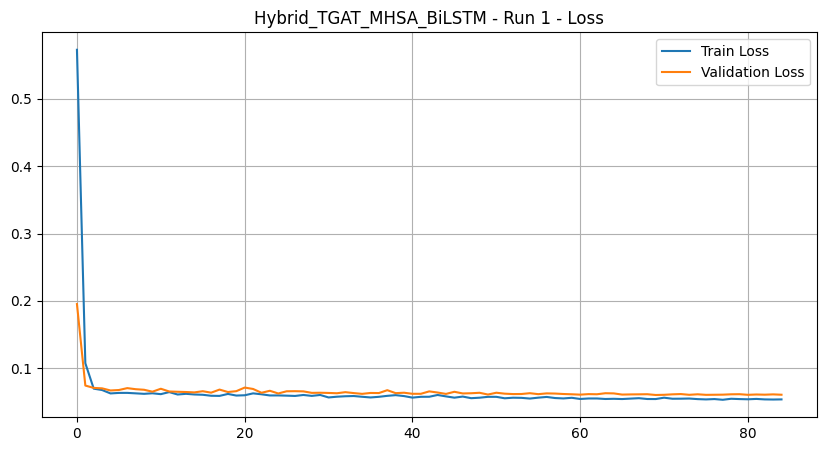

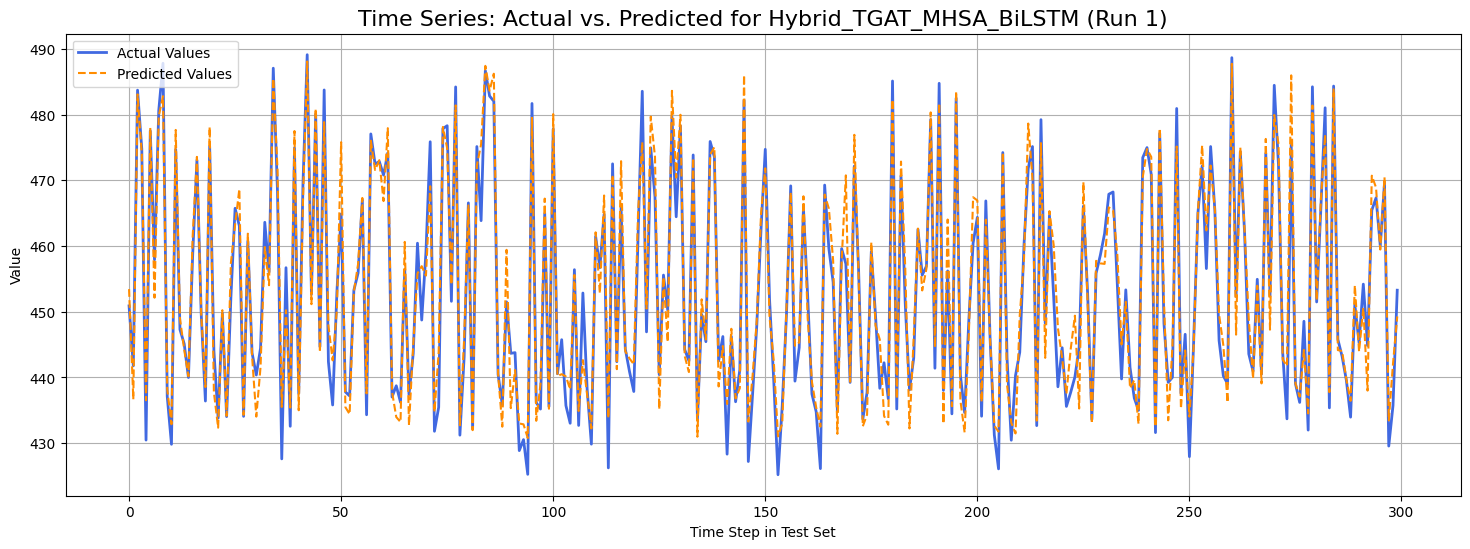



--- 🏁 FINAL Hybrid_TGAT_MHSA_BiLSTM RESULTS ---
                  Model  Run     MSE   RMSE     R2
Hybrid_TGAT_MHSA_BiLSTM    1 16.2146 4.0267 0.9425


In [ ]:
# proposed_model_with_timeseries_plot.py

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import pickle
from collections import defaultdict
from tqdm import tqdm
import sys
import requests
from zipfile import ZipFile
from io import BytesIO


# --- Configuration (Tuned for High Performance) ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 128
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2
N_RUNS = 5
EPOCHS = 100
BATCH_SIZE = 256
PATIENCE = 15
LEARNING_RATE = 0.001
WARMUP_EPOCHS = 5
NUM_NEIGHBORS = 4

# --- Helper Functions and Classes ---
def plot_loss(h, model_name, run):
    plt.figure(figsize=(10, 5))
    plt.plot(h['train'], label='Train Loss')
    plt.plot(h['val'], label='Validation Loss')
    plt.title(f'{model_name} - Run {run} - Loss')
    plt.legend(); plt.grid(True); plt.show(); plt.savefig(f"{model_name}_power_run{run}_loss.png"); plt.close()

def plot_predictions(yt, yp, model_name, run):
    plt.figure(figsize=(10, 10))
    plt.scatter(yt, yp, alpha=0.3, edgecolors='k', s=20)
    plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], '--r', linewidth=2, label='Ideal Fit')
    plt.title(f'{model_name} - Run {run} - Predictions (R2: {r2_score(yt, yp):.4f})')
    plt.xlabel("Actual Values"); plt.ylabel("Predicted Values")
    plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_power_run{run}_predictions.png"); plt.close()

# <<< NEW: Function to plot the time series comparison >>>
def plot_time_series(truths, preds, model_name, run_number):
    """Plots the actual vs. predicted values as a time series."""
    sample_points_to_plot = 300
    plt.figure(figsize=(18, 6))
    plt.plot(truths[-sample_points_to_plot:], label='Actual Values', color='royalblue', linewidth=2)
    plt.plot(preds[-sample_points_to_plot:], label='Predicted Values', color='darkorange', linestyle='--')
    plt.title(f'Time Series: Actual vs. Predicted for {model_name} (Run {run_number})', fontsize=16)
    plt.xlabel('Time Step in Test Set')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{model_name}_power_run{run_number}_timeseries.png")
    plt.show()
    plt.close()


class NeighborFinder:
    def __init__(self, adj_list):
        self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64)
        out_ngh_ts_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.float64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, [])
            recent_neighbors = sorted([n for n in neighbors if n[1] <= cut_time],
                                      key=lambda x: x[1],
                                      reverse=True)[:num_neighbors]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]
                out_ngh_ts_batch[i, :len(recent_neighbors)] = [x[1] for x in recent_neighbors]
        return out_ngh_node_batch, out_ngh_ts_batch

class SinusoidalTimeEncode(nn.Module):
    def __init__(self, dimension):
        super().__init__(); self.dimension = dimension
    def forward(self, t):
        t = t.unsqueeze(dim=-1)
        div = torch.exp(torch.arange(0, self.dimension, 2, device=DEVICE).float() * -(np.log(10000.0) / self.dimension))
        pe = torch.zeros(*t.shape[:2], self.dimension, device=DEVICE)
        pe[..., 0::2] = torch.sin(t * div); pe[..., 1::2] = torch.cos(t * div)
        return pe

class TemporalAttentionLayer(nn.Module):
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__(); self.h, self.d = n_heads, feat_dim // n_heads
        self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3))
        self.t_proj = nn.Linear(feat_dim, feat_dim); self.o_proj = nn.Linear(feat_dim, feat_dim); self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat, t_enc):
        b, n_ngh, _ = ngh_feat.size()
        q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2)
        k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        t = self.t_proj(t_enc).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        scores = torch.sum((q * k) + t, dim=-1) / np.sqrt(self.d)
        attn = torch.softmax(scores, dim=-1)
        out = torch.sum(attn.unsqueeze(-1) * v, dim=2)
        return self.dropout(self.o_proj(out.view(b, -1)))

class TGAT_MHSA_BiLSTM(nn.Module):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout, bilstm_h, num_direct_features):
        super().__init__()
        self.neighbor_finder = neighbor_finder
        self.node_features = torch.nn.Parameter(node_features, requires_grad=False)
        self.embed_dim = bilstm_h * 2
        self.feat_proj = nn.Linear(feat_dim, self.embed_dim)
        self.time_enc = SinusoidalTimeEncode(self.embed_dim)
        self.attn_layers = nn.ModuleList([TemporalAttentionLayer(self.embed_dim, n_heads, dropout) for _ in range(n_layers)])
        self.norm_layers = nn.ModuleList([nn.LayerNorm(self.embed_dim) for _ in range(n_layers)])
        self.mhsa = nn.MultiheadAttention(bilstm_h * 2, num_heads=n_heads, batch_first=True, dropout=dropout)
        self.bilstm = nn.LSTM(bilstm_h * 2, bilstm_h, batch_first=True, bidirectional=True)
        self.seq_norm = nn.LayerNorm(bilstm_h * 2)
        self.direct_feature_proj = nn.Sequential(
            nn.Linear(num_direct_features, bilstm_h),
            nn.ReLU(),
            nn.Linear(bilstm_h, bilstm_h * 2)
        )
        self.reg_head = nn.Sequential(
            nn.Linear(bilstm_h * 4, bilstm_h * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(bilstm_h * 2, bilstm_h), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(bilstm_h, 1)
        )

    def forward(self, src_nodes, timestamps, direct_features):
        src_feat = self.feat_proj(self.node_features[src_nodes])
        layer_outputs = []
        for i in range(len(self.attn_layers)):
            ngh_idx, ngh_ts = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS)
            ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE)
            ngh_feat = self.feat_proj(self.node_features[ngh_idx_t.flatten()]).view(len(src_nodes), NUM_NEIGHBORS, -1)
            t_deltas = timestamps.unsqueeze(1) - torch.from_numpy(ngh_ts).float().to(DEVICE)
            t_enc = self.time_enc(t_deltas); mask = (ngh_idx_t != 0).unsqueeze(-1)
            agg_embed = self.attn_layers[i](src_feat, ngh_feat * mask, t_enc)
            src_feat = self.norm_layers[i](agg_embed + src_feat)
            layer_outputs.append(src_feat)
        tgat_sequence = torch.stack(layer_outputs, dim=1)
        mhsa_out, _ = self.mhsa(tgat_sequence, tgat_sequence, tgat_sequence)
        mhsa_sequence = self.seq_norm(tgat_sequence + mhsa_out)
        bilstm_out, _ = self.bilstm(mhsa_sequence)
        graph_representation = torch.mean(bilstm_out, dim=1)
        direct_representation = self.direct_feature_proj(direct_features)
        combined_representation = torch.cat([graph_representation, direct_representation], dim=1)
        return self.reg_head(combined_representation)

def train_and_evaluate_run(model, model_name, train_loader, val_loader, test_loader, target_scaler, run_number):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    warmup_scheduler = LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, (e + 1) / WARMUP_EPOCHS))
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
    criterion = nn.MSELoss()
    best_val_loss, patience_counter, history = float('inf'), 0, defaultdict(list)

    for epoch in range(EPOCHS):
        model.train(); epoch_loss = 0
        for node_ids, ts, direct_features, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            optimizer.zero_grad()
            node_ids, ts, direct_features, y = node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE), y.to(DEVICE)
            pred = model(node_ids, ts, direct_features); loss = criterion(pred, y)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
            epoch_loss += loss.item()
        history['train'].append(epoch_loss / len(train_loader))
        model.eval(); val_loss = 0
        with torch.no_grad():
            for node_ids, ts, direct_features, y in val_loader:
                pred = model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE))
                val_loss += criterion(pred, y.to(DEVICE)).item()
        avg_val_loss = val_loss / len(val_loader); history['val'].append(avg_val_loss)
        if epoch < WARMUP_EPOCHS: warmup_scheduler.step()
        else: cosine_scheduler.step()
        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            torch.save(model.state_dict(), f'best_{model_name}_{run_number}.pth')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"   -> Early stopping at epoch {epoch+1}"); break

    model.load_state_dict(torch.load(f'best_{model_name}_{run_number}.pth')); model.eval(); preds, truths = [], []
    with torch.no_grad():
        for node_ids, ts, direct_features, y in test_loader:
            preds.append(model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE)).cpu())
            truths.append(y.cpu())
    preds_inv = target_scaler.inverse_transform(torch.cat(preds).numpy())
    truths_inv = target_scaler.inverse_transform(torch.cat(truths).numpy())

    plot_loss(history, model_name, run_number)
    plot_predictions(truths_inv, preds_inv, model_name, run_number)
    # <<< NEW: Call the time series plotting function >>>
    plot_time_series(truths_inv, preds_inv, model_name, run_number)

    mse = mean_squared_error(truths_inv, preds_inv); r2 = r2_score(truths_inv, preds_inv)
    return {'Model': model_name, 'Run': run_number, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

if __name__ == '__main__':
    try:
        node_features_array = np.load('nodes_power_tgat.npy')
        with open('adj_list_power_tgat.pkl', 'rb') as f:
            adj_list = pickle.load(f)
        DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'
        if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
            print("Downloading original CCPP data..."); response = requests.get(DATA_URL); response.raise_for_status()
            with ZipFile(BytesIO(response.content)) as z: z.extractall()
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')
    except FileNotFoundError:
        print("❌ ERROR: Data not found. Please run the preprocessing script first."); sys.exit()

    target = original_df[['PE']].values; direct_features = original_df[['AT', 'V', 'AP', 'RH']].values
    feature_scaler = StandardScaler().fit(direct_features); target_scaler = StandardScaler().fit(target)
    direct_features_scaled = feature_scaler.transform(direct_features); target_scaled = target_scaler.transform(target)
    node_ids = np.full(len(original_df), 4); timestamps = np.arange(len(original_df))
    node_features = torch.tensor(node_features_array, dtype=torch.float32)
    full_ds = TensorDataset(torch.from_numpy(node_ids).long(),
                              torch.from_numpy(timestamps).float(),
                              torch.from_numpy(direct_features_scaled).float(),
                              torch.from_numpy(target_scaled).float())
    train_size = int(len(original_df) * 0.7); val_size = int(len(original_df) * 0.15)
    train_ds = Subset(full_ds, range(train_size)); val_ds = Subset(full_ds, range(train_size, train_size + val_size)); test_ds = Subset(full_ds, range(train_size + val_size, len(original_df)))
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True); val_loader = DataLoader(val_ds, BATCH_SIZE); test_loader = DataLoader(test_ds, BATCH_SIZE)
    neighbor_finder = NeighborFinder(adj_list); feat_dim = node_features.shape[1]

    model_name = "Hybrid_TGAT_MHSA_BiLSTM"
    model_args = {'neighbor_finder': neighbor_finder, 'node_features': node_features, 'feat_dim': feat_dim,
                  'n_layers': N_LAYERS, 'n_heads': N_HEADS, 'dropout': DROPOUT_RATE, 'bilstm_h': HIDDEN_DIM,
                  'num_direct_features': direct_features.shape[1]}

    print(f"\n--- Starting Run for {model_name} ---")
    model = TGAT_MHSA_BiLSTM(**model_args).to(DEVICE)
    metrics = train_and_evaluate_run(model, model_name, train_loader, val_loader, test_loader, target_scaler, 1)

    print("\n\n" + "="*80 + f"\n--- 🏁 FINAL {model_name} RESULTS ---\n" + "="*80)
    final_results_df = pd.DataFrame([metrics])
    for col in ['MSE', 'RMSE', 'R2']:
        final_results_df[col] = final_results_df[col].apply(lambda x: f"{x:.4f}")
    print(final_results_df.to_string(index=False))

In [ ]:
# TGAT_Only_Optimized.py

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import pickle
from collections import defaultdict
from tqdm import tqdm
import sys
import requests
from zipfile import ZipFile
from io import BytesIO

# --- Optimized Hyperparameters ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 128
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2  # <<< CHANGED: Added a small dropout for regularization in the head
N_RUNS = 1
EPOCHS = 100
BATCH_SIZE = 256    # <<< CHANGED: Increased batch size for more stable gradients
PATIENCE = 15
LEARNING_RATE = 0.0001 # <<< CHANGED: Slightly lower LR for more stable training
WARMUP_EPOCHS = 5
NUM_NEIGHBORS = 4

# --- Helper Functions and Classes ---
def plot_loss(h, model_name, run):
    plt.figure(figsize=(10, 5))
    plt.plot(h['train'], label='Train Loss')
    plt.plot(h['val'], label='Validation Loss')
    plt.title(f'{model_name} - Run {run} - Loss')
    plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_power_run{run}_loss.png"); plt.close()

def plot_predictions(yt, yp, model_name, run):
    plt.figure(figsize=(10, 10))
    plt.scatter(yt, yp, alpha=0.3, edgecolors='k', s=20)
    plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], '--r', linewidth=2, label='Ideal Fit')
    plt.title(f'{model_name} - Run {run} - Predictions (R2: {r2_score(yt, yp):.4f})')
    plt.xlabel("Actual Values"); plt.ylabel("Predicted Values")
    plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_power_run{run}_predictions.png"); plt.close()

class NeighborFinder:
    def __init__(self, adj_list):
        self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, [])
            recent_neighbors = [n for n in neighbors if n[1] == cut_time]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]
        return out_ngh_node_batch

class TemporalAttentionLayer(nn.Module):
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__(); self.h, self.d = n_heads, feat_dim // n_heads
        self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3))
        self.o_proj = nn.Linear(feat_dim, feat_dim); self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat):
        b, n_ngh, _ = ngh_feat.size()
        q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2)
        k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        scores = torch.sum(q * k, dim=-1) / np.sqrt(self.d)
        attn = torch.softmax(scores, dim=-1)
        out = torch.sum(attn.unsqueeze(-1) * v, dim=2)
        return self.dropout(self.o_proj(out.view(b, -1)))

# --- MODEL DEFINITION FOR TGAT_Only ---
class TGAT_Only(nn.Module):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout):
        super().__init__()
        self.neighbor_finder = neighbor_finder
        self.node_features = torch.nn.Parameter(node_features, requires_grad=False)
        self.feat_dim = feat_dim
        self.attn_layers = nn.ModuleList([TemporalAttentionLayer(feat_dim, n_heads, dropout=0.0) for _ in range(n_layers)]) # Set internal dropout to 0
        self.norm_layers = nn.ModuleList([nn.LayerNorm(feat_dim) for _ in range(n_layers)])

        # <<< CHANGED: Strengthened the regression head and integrated direct features
        self.direct_feature_dim = 4 # AT, V, AP, RH
        self.reg_head = nn.Sequential(
            nn.Linear(feat_dim + self.direct_feature_dim, feat_dim), # Input now includes direct features
            nn.LayerNorm(feat_dim),
            nn.GELU(),
            nn.Dropout(dropout), # Use the main dropout rate here
            nn.Linear(feat_dim, 1)
        )

    def forward(self, src_nodes, timestamps, direct_features): # direct_features is now used
        src_feat = self.node_features[src_nodes]
        for i in range(len(self.attn_layers)):
            ngh_idx = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS)
            ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE)
            ngh_feat = self.node_features[ngh_idx_t.flatten()].view(len(src_nodes), -1, self.feat_dim)
            agg = self.attn_layers[i](src_feat, ngh_feat)
            src_feat = self.norm_layers[i](agg + src_feat) # Residual connection

        # <<< CHANGED: Concatenate the graph features with the direct input features
        combined_feat = torch.cat([src_feat, direct_features], dim=1)
        return self.reg_head(combined_feat)

def train_and_evaluate_run(model, model_name, train_loader, val_loader, test_loader, target_scaler, run_number):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) # <<< CHANGED: Increased weight decay
    warmup_scheduler = LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, (e + 1) / WARMUP_EPOCHS))
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
    criterion = nn.MSELoss()
    best_val_loss, patience_counter, history = float('inf'), 0, defaultdict(list)

    for epoch in range(EPOCHS):
        model.train(); epoch_loss = 0
        for node_ids, ts, direct_features, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            optimizer.zero_grad()
            node_ids, ts, direct_features, y = node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE), y.to(DEVICE)
            pred = model(node_ids, ts, direct_features)
            loss = criterion(pred.squeeze(), y.squeeze()) # <<< CHANGED: Squeeze to ensure shapes match
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        history['train'].append(epoch_loss / len(train_loader))

        model.eval(); val_loss = 0
        with torch.no_grad():
            for node_ids, ts, direct_features, y in val_loader:
                pred = model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE))
                val_loss += criterion(pred.squeeze(), y.to(DEVICE).squeeze()).item() # <<< CHANGED: Squeeze to ensure shapes match
        avg_val_loss = val_loss / len(val_loader)
        history['val'].append(avg_val_loss)

        if epoch < WARMUP_EPOCHS: warmup_scheduler.step()
        else: cosine_scheduler.step()

        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            torch.save(model.state_dict(), f'best_{model_name}_{run_number}.pth')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"   -> Early stopping at epoch {epoch+1}"); break

    model.load_state_dict(torch.load(f'best_{model_name}_{run_number}.pth')); model.eval(); preds, truths = [], []
    with torch.no_grad():
        for node_ids, ts, direct_features, y in test_loader:
            preds.append(model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE)).cpu())
            truths.append(y.cpu())

    preds_inv = target_scaler.inverse_transform(torch.cat(preds).numpy())
    truths_inv = target_scaler.inverse_transform(torch.cat(truths).numpy())

    plot_loss(history, model_name, run_number)
    plot_predictions(truths_inv, preds_inv, model_name, run_number)

    mse = mean_squared_error(truths_inv, preds_inv); r2 = r2_score(truths_inv, preds_inv)
    return {'Model': model_name, 'Run': run_number, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

if __name__ == '__main__':
    try:
        # Load pre-computed graph files
        node_features_array = np.load('nodes_power_tgat.npy')
        with open('adj_list_power_tgat.pkl', 'rb') as f:
            adj_list = pickle.load(f)

        # Load the ORIGINAL dataset to get per-timestamp features and target
        if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
            print("Downloading original CCPP data..."); response = requests.get('https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'); response.raise_for_status()
            with ZipFile(BytesIO(response.content)) as z: z.extractall()
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')

    except FileNotFoundError:
        print("❌ ERROR: Data not found. Please run the preprocessing script first."); sys.exit()

    # Prepare data for the DataLoader
    target = original_df[['PE']].values
    direct_features = original_df[['AT', 'V', 'AP', 'RH']].values
    feature_scaler = StandardScaler().fit(direct_features)
    target_scaler = StandardScaler().fit(target)
    direct_features_scaled = feature_scaler.transform(direct_features)
    target_scaled = target_scaler.transform(target)

    # Prepare graph-related data
    node_map = {name: i for i, name in enumerate(original_df.columns)}
    target_node_id = node_map['PE']
    node_ids = np.full(len(original_df), target_node_id)
    timestamps = np.arange(len(original_df))

    # Create the TensorDataset and DataLoaders
    node_features = torch.tensor(node_features_array, dtype=torch.float32)
    full_ds = TensorDataset(torch.from_numpy(node_ids).long(),
                              torch.from_numpy(timestamps).float(),
                              torch.from_numpy(direct_features_scaled).float(),
                              torch.from_numpy(target_scaled).float())

    train_size = int(len(original_df) * 0.7); val_size = int(len(original_df) * 0.15)
    train_ds = Subset(full_ds, range(train_size))
    val_ds = Subset(full_ds, range(train_size, train_size + val_size))
    test_ds = Subset(full_ds, range(train_size + val_size, len(original_df)))
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, BATCH_SIZE)
    test_loader = DataLoader(test_ds, BATCH_SIZE)

    neighbor_finder = NeighborFinder(adj_list); feat_dim = node_features.shape[1]
    model_name = "TGAT_Only"

    final_results = []
    for i in range(1, N_RUNS + 1):
        print(f"\n--- Starting Run {i}/{N_RUNS} for {model_name} ---")
        model = TGAT_Only(
            neighbor_finder=neighbor_finder,
            node_features=node_features,
            feat_dim=feat_dim,
            n_layers=N_LAYERS,
            n_heads=N_HEADS,
            dropout=DROPOUT_RATE
        ).to(DEVICE)

        metrics = train_and_evaluate_run(model, model_name, train_loader, val_loader, test_loader, target_scaler, i)
        final_results.append(metrics)

    print("\n\n" + "="*80 + f"\n--- 🏁 FINAL {model_name} RESULTS (Averaged over {N_RUNS} runs) ---\n" + "="*80)
    results_df = pd.DataFrame(final_results)

    avg_metrics = {'Model': model_name}
    numeric_cols = results_df.select_dtypes(include=np.number).columns.tolist()
    for col in numeric_cols:
        if col != 'Run':
            mean_val, std_val = results_df[col].mean(), results_df[col].std()
            avg_metrics[f'Avg_{col.upper()}'] = f"{mean_val:.4f} ± {std_val:.4f}"

    print(pd.DataFrame([avg_metrics]).to_string(index=False))


--- Starting Run 1/1 for TGAT_Only ---




--- 🏁 FINAL TGAT_Only RESULTS (Averaged over 1 runs) ---
    Model       Avg_MSE     Avg_RMSE       Avg_R2
TGAT_Only 79.4717 ± nan 8.9147 ± nan 0.7180 ± nan


In [ ]:
# TGAT_Only_Optimized.py

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import pickle
from collections import defaultdict
from tqdm import tqdm
import sys
import requests
from zipfile import ZipFile
from io import BytesIO

# --- Optimized Hyperparameters ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 128
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2  # <<< CHANGED: Added a small dropout for regularization in the head
N_RUNS = 4
EPOCHS = 100
BATCH_SIZE = 256    # <<< CHANGED: Increased batch size for more stable gradients
PATIENCE = 15
LEARNING_RATE = 0.0001 # <<< CHANGED: Slightly lower LR for more stable training
WARMUP_EPOCHS = 5
NUM_NEIGHBORS = 4

# --- Helper Functions and Classes ---
def plot_loss(h, model_name, run):
    plt.figure(figsize=(10, 5))
    plt.plot(h['train'], label='Train Loss')
    plt.plot(h['val'], label='Validation Loss')
    plt.title(f'{model_name} - Run {run} - Loss')
    plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_power_run{run}_loss.png"); plt.close()

def plot_predictions(yt, yp, model_name, run):
    plt.figure(figsize=(10, 10))
    plt.scatter(yt, yp, alpha=0.3, edgecolors='k', s=20)
    plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], '--r', linewidth=2, label='Ideal Fit')
    plt.title(f'{model_name} - Run {run} - Predictions (R2: {r2_score(yt, yp):.4f})')
    plt.xlabel("Actual Values"); plt.ylabel("Predicted Values")
    plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_power_run{run}_predictions.png"); plt.close()

class NeighborFinder:
    def __init__(self, adj_list):
        self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, [])
            recent_neighbors = [n for n in neighbors if n[1] == cut_time]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]
        return out_ngh_node_batch

class TemporalAttentionLayer(nn.Module):
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__(); self.h, self.d = n_heads, feat_dim // n_heads
        self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3))
        self.o_proj = nn.Linear(feat_dim, feat_dim); self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat):
        b, n_ngh, _ = ngh_feat.size()
        q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2)
        k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        scores = torch.sum(q * k, dim=-1) / np.sqrt(self.d)
        attn = torch.softmax(scores, dim=-1)
        out = torch.sum(attn.unsqueeze(-1) * v, dim=2)
        return self.dropout(self.o_proj(out.view(b, -1)))

# --- MODEL DEFINITION FOR TGAT_Only ---
class TGAT_Only(nn.Module):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout):
        super().__init__()
        self.neighbor_finder = neighbor_finder
        self.node_features = torch.nn.Parameter(node_features, requires_grad=False)
        self.feat_dim = feat_dim
        self.attn_layers = nn.ModuleList([TemporalAttentionLayer(feat_dim, n_heads, dropout=0.0) for _ in range(n_layers)]) # Set internal dropout to 0
        self.norm_layers = nn.ModuleList([nn.LayerNorm(feat_dim) for _ in range(n_layers)])

        # <<< CHANGED: Strengthened the regression head and integrated direct features
        self.direct_feature_dim = 4 # AT, V, AP, RH
        self.reg_head = nn.Sequential(
            nn.Linear(feat_dim + self.direct_feature_dim, feat_dim), # Input now includes direct features
            nn.LayerNorm(feat_dim),
            nn.GELU(),
            nn.Dropout(dropout), # Use the main dropout rate here
            nn.Linear(feat_dim, 1)
        )

    def forward(self, src_nodes, timestamps, direct_features): # direct_features is now used
        src_feat = self.node_features[src_nodes]
        for i in range(len(self.attn_layers)):
            ngh_idx = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS)
            ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE)
            ngh_feat = self.node_features[ngh_idx_t.flatten()].view(len(src_nodes), -1, self.feat_dim)
            agg = self.attn_layers[i](src_feat, ngh_feat)
            src_feat = self.norm_layers[i](agg + src_feat) # Residual connection

        # <<< CHANGED: Concatenate the graph features with the direct input features
        combined_feat = torch.cat([src_feat, direct_features], dim=1)
        return self.reg_head(combined_feat)

def train_and_evaluate_run(model, model_name, train_loader, val_loader, test_loader, target_scaler, run_number):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) # <<< CHANGED: Increased weight decay
    warmup_scheduler = LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, (e + 1) / WARMUP_EPOCHS))
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
    criterion = nn.MSELoss()
    best_val_loss, patience_counter, history = float('inf'), 0, defaultdict(list)

    for epoch in range(EPOCHS):
        model.train(); epoch_loss = 0
        for node_ids, ts, direct_features, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            optimizer.zero_grad()
            node_ids, ts, direct_features, y = node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE), y.to(DEVICE)
            pred = model(node_ids, ts, direct_features)
            loss = criterion(pred.squeeze(), y.squeeze()) # <<< CHANGED: Squeeze to ensure shapes match
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        history['train'].append(epoch_loss / len(train_loader))

        model.eval(); val_loss = 0
        with torch.no_grad():
            for node_ids, ts, direct_features, y in val_loader:
                pred = model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE))
                val_loss += criterion(pred.squeeze(), y.to(DEVICE).squeeze()).item() # <<< CHANGED: Squeeze to ensure shapes match
        avg_val_loss = val_loss / len(val_loader)
        history['val'].append(avg_val_loss)

        if epoch < WARMUP_EPOCHS: warmup_scheduler.step()
        else: cosine_scheduler.step()

        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            torch.save(model.state_dict(), f'best_{model_name}_{run_number}.pth')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"   -> Early stopping at epoch {epoch+1}"); break

    model.load_state_dict(torch.load(f'best_{model_name}_{run_number}.pth')); model.eval(); preds, truths = [], []
    with torch.no_grad():
        for node_ids, ts, direct_features, y in test_loader:
            preds.append(model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE)).cpu())
            truths.append(y.cpu())

    preds_inv = target_scaler.inverse_transform(torch.cat(preds).numpy())
    truths_inv = target_scaler.inverse_transform(torch.cat(truths).numpy())

    plot_loss(history, model_name, run_number)
    plot_predictions(truths_inv, preds_inv, model_name, run_number)

    mse = mean_squared_error(truths_inv, preds_inv); r2 = r2_score(truths_inv, preds_inv)
    return {'Model': model_name, 'Run': run_number, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

if __name__ == '__main__':
    try:
        # Load pre-computed graph files
        node_features_array = np.load('nodes_power_tgat.npy')
        with open('adj_list_power_tgat.pkl', 'rb') as f:
            adj_list = pickle.load(f)

        # Load the ORIGINAL dataset to get per-timestamp features and target
        if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
            print("Downloading original CCPP data..."); response = requests.get('https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'); response.raise_for_status()
            with ZipFile(BytesIO(response.content)) as z: z.extractall()
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')

    except FileNotFoundError:
        print("❌ ERROR: Data not found. Please run the preprocessing script first."); sys.exit()

    # Prepare data for the DataLoader
    target = original_df[['PE']].values
    direct_features = original_df[['AT', 'V', 'AP', 'RH']].values
    feature_scaler = StandardScaler().fit(direct_features)
    target_scaler = StandardScaler().fit(target)
    direct_features_scaled = feature_scaler.transform(direct_features)
    target_scaled = target_scaler.transform(target)

    # Prepare graph-related data
    node_map = {name: i for i, name in enumerate(original_df.columns)}
    target_node_id = node_map['PE']
    node_ids = np.full(len(original_df), target_node_id)
    timestamps = np.arange(len(original_df))

    # Create the TensorDataset and DataLoaders
    node_features = torch.tensor(node_features_array, dtype=torch.float32)
    full_ds = TensorDataset(torch.from_numpy(node_ids).long(),
                              torch.from_numpy(timestamps).float(),
                              torch.from_numpy(direct_features_scaled).float(),
                              torch.from_numpy(target_scaled).float())

    train_size = int(len(original_df) * 0.7); val_size = int(len(original_df) * 0.15)
    train_ds = Subset(full_ds, range(train_size))
    val_ds = Subset(full_ds, range(train_size, train_size + val_size))
    test_ds = Subset(full_ds, range(train_size + val_size, len(original_df)))
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, BATCH_SIZE)
    test_loader = DataLoader(test_ds, BATCH_SIZE)

    neighbor_finder = NeighborFinder(adj_list); feat_dim = node_features.shape[1]
    model_name = "TGAT_Only"

    final_results = []
    for i in range(1, N_RUNS + 1):
        print(f"\n--- Starting Run {i}/{N_RUNS} for {model_name} ---")
        model = TGAT_Only(
            neighbor_finder=neighbor_finder,
            node_features=node_features,
            feat_dim=feat_dim,
            n_layers=N_LAYERS,
            n_heads=N_HEADS,
            dropout=DROPOUT_RATE
        ).to(DEVICE)

        metrics = train_and_evaluate_run(model, model_name, train_loader, val_loader, test_loader, target_scaler, i)
        final_results.append(metrics)

    print("\n\n" + "="*80 + f"\n--- 🏁 FINAL {model_name} RESULTS (Averaged over {N_RUNS} runs) ---\n" + "="*80)
    results_df = pd.DataFrame(final_results)

    avg_metrics = {'Model': model_name}
    numeric_cols = results_df.select_dtypes(include=np.number).columns.tolist()
    for col in numeric_cols:
        if col != 'Run':
            mean_val, std_val = results_df[col].mean(), results_df[col].std()
            avg_metrics[f'Avg_{col.upper()}'] = f"{mean_val:.4f} ± {std_val:.4f}"

    print(pd.DataFrame([avg_metrics]).to_string(index=False))


--- Starting Run 1/4 for TGAT_Only ---



--- Starting Run 2/4 for TGAT_Only ---



--- Starting Run 3/4 for TGAT_Only ---



--- Starting Run 4/4 for TGAT_Only ---




--- 🏁 FINAL TGAT_Only RESULTS (Averaged over 4 runs) ---
    Model           Avg_MSE        Avg_RMSE          Avg_R2
TGAT_Only 75.5356 ± 20.4483 8.6302 ± 1.1866 0.7320 ± 0.0725


In [ ]:
# plot_only.py

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import pickle
import sys
import requests
from zipfile import ZipFile
from io import BytesIO

# --- Hyperparameters (must match the trained model) ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 128
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2
BATCH_SIZE = 256
NUM_NEIGHBORS = 4
RUN_TO_PLOT = 1 # Specify which run's model you want to use

# --- Plotting Function ---
def plot_time_series(yt, yp, model_name, run):
    """
    Plots the actual vs. predicted values as a time series.
    """
    plt.figure(figsize=(15, 6))
    plt.plot(yt, label='Actual Values', color='blue', linewidth=1.5, alpha=0.8)
    plt.plot(yp, label='Predicted Values', color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    plt.title(f'{model_name} - Run {run} - Time Series of Actual vs. Predicted (Test Set)')
    plt.xlabel("Time Step")
    plt.ylabel("Power Output (PE)")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{model_name}_power_run{run}_timeseries_only.png")
    plt.close()
    print(f"✅ Time series plot saved to: {model_name}_power_run{run}_timeseries_only.png")

# --- Model Classes (must match the trained model) ---
class NeighborFinder:
    def __init__(self, adj_list):
        self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, [])
            recent_neighbors = [n for n in neighbors if n[1] == cut_time]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]
        return out_ngh_node_batch

class TemporalAttentionLayer(nn.Module):
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__(); self.h, self.d = n_heads, feat_dim // n_heads
        self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3))
        self.o_proj = nn.Linear(feat_dim, feat_dim); self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat):
        b, n_ngh, _ = ngh_feat.size()
        q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2)
        k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        scores = torch.sum(q * k, dim=-1) / np.sqrt(self.d)
        attn = torch.softmax(scores, dim=-1)
        out = torch.sum(attn.unsqueeze(-1) * v, dim=2)
        return self.dropout(self.o_proj(out.view(b, -1)))

class TGAT_Only(nn.Module):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout):
        super().__init__()
        self.neighbor_finder = neighbor_finder
        self.node_features = torch.nn.Parameter(node_features, requires_grad=False)
        self.feat_dim = feat_dim
        self.attn_layers = nn.ModuleList([TemporalAttentionLayer(feat_dim, n_heads, dropout=0.0) for _ in range(n_layers)])
        self.norm_layers = nn.ModuleList([nn.LayerNorm(feat_dim) for _ in range(n_layers)])
        self.direct_feature_dim = 4
        self.reg_head = nn.Sequential(
            nn.Linear(feat_dim + self.direct_feature_dim, feat_dim),
            nn.LayerNorm(feat_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(feat_dim, 1)
        )
    def forward(self, src_nodes, timestamps, direct_features):
        src_feat = self.node_features[src_nodes]
        for i in range(len(self.attn_layers)):
            ngh_idx = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS)
            ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE)
            ngh_feat = self.node_features[ngh_idx_t.flatten()].view(len(src_nodes), -1, self.feat_dim)
            agg = self.attn_layers[i](src_feat, ngh_feat)
            src_feat = self.norm_layers[i](agg + src_feat)
        combined_feat = torch.cat([src_feat, direct_features], dim=1)
        return self.reg_head(combined_feat)


if __name__ == '__main__':
    model_name = "TGAT_Only"
    model_path = f'best_{model_name}_{RUN_TO_PLOT}.pth'

    # --- 1. Load Data and Preprocessing Objects ---
    print("Loading data...")
    try:
        node_features_array = np.load('nodes_power_tgat.npy')
        with open('adj_list_power_tgat.pkl', 'rb') as f:
            adj_list = pickle.load(f)
        if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
            print("Downloading CCPP data..."); response = requests.get('https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'); response.raise_for_status()
            with ZipFile(BytesIO(response.content)) as z: z.extractall()
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')

    except FileNotFoundError as e:
        print(f"❌ ERROR: Data file not found: {e}. Make sure all data files are in the same directory."); sys.exit()

    # Recreate scalers and test data loader
    target = original_df[['PE']].values
    direct_features = original_df[['AT', 'V', 'AP', 'RH']].values
    target_scaler = StandardScaler().fit(target) # Must be the same as during training
    direct_features_scaled = StandardScaler().fit_transform(direct_features)

    node_map = {name: i for i, name in enumerate(original_df.columns)}
    target_node_id = node_map['PE']
    node_ids = np.full(len(original_df), target_node_id)
    timestamps = np.arange(len(original_df))

    node_features = torch.tensor(node_features_array, dtype=torch.float32)
    full_ds = TensorDataset(torch.from_numpy(node_ids).long(),
                              torch.from_numpy(timestamps).float(),
                              torch.from_numpy(direct_features_scaled).float(),
                              torch.from_numpy(target_scaled).float())

    train_size = int(len(original_df) * 0.7); val_size = int(len(original_df) * 0.15)
    test_ds = Subset(full_ds, range(train_size + val_size, len(original_df)))
    test_loader = DataLoader(test_ds, BATCH_SIZE)

    # --- 2. Initialize Model and Load Weights ---
    print(f"Loading model weights from '{model_path}'...")
    if not os.path.exists(model_path):
        print(f"❌ ERROR: Model weights file not found at '{model_path}'"); sys.exit()

    neighbor_finder = NeighborFinder(adj_list); feat_dim = node_features.shape[1]
    model = TGAT_Only(neighbor_finder=neighbor_finder, node_features=node_features,
                      feat_dim=feat_dim, n_layers=N_LAYERS, n_heads=N_HEADS,
                      dropout=DROPOUT_RATE).to(DEVICE)

    model.load_state_dict(torch.load(model_path, map_location=DEVICE))

    # --- 3. Generate Predictions on Test Set ---
    print("Generating predictions on the test set...")
    model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for node_ids, ts, direct_features_batch, y in test_loader:
            preds.append(model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features_batch.to(DEVICE)).cpu())
            truths.append(y.cpu())

    # Inverse transform to get actual values
    preds_inv = target_scaler.inverse_transform(torch.cat(preds).numpy())
    truths_inv = target_scaler.inverse_transform(torch.cat(truths).numpy())

    # --- 4. Plot and Save the Time Series Graph ---
    plot_time_series(truths_inv, preds_inv, model_name, RUN_TO_PLOT)

Loading data...
Loading model weights from 'best_TGAT_Only_1.pth'...
Generating predictions on the test set...
✅ Time series plot saved to: TGAT_Only_power_run1_timeseries_only.png


In [ ]:
!zip -r /content/powerplant_tgat_noise_graph_4_runs.zip /content/
from google.colab import files
files.download('/content/powerplant_tgat_noise_graph_4_runs.zip')

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.08.12/ (stored 0%)
  adding: content/.config/logs/2025.08.12/13.38.32.996844.log (deflated 57%)
  adding: content/.config/logs/2025.08.12/13.38.42.123561.log (deflated 57%)
  adding: content/.config/logs/2025.08.12/13.38.16.965842.log (deflated 58%)
  adding: content/.config/logs/2025.08.12/13.38.42.799891.log (deflated 56%)
  adding: content/.config/logs/2025.08.12/13.37.44.841798.log (deflated 92%)
  adding: content/.config/logs/2025.08.12/13.38.25.896252.log (deflated 86%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: conten

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>